# 06 — Unsupervised Anomaly Detection: Convolutional Autoencoder

## Goal

Train a convolutional autoencoder **only on normal pump signals**. At inference time,
abnormal signals produce higher reconstruction error because the model has only ever
seen normal patterns. Reconstruction error is the anomaly score.

## Why this matters

In real underground pipe inspection, **labelled blockage recordings are scarce or non-existent**.
You have years of normal operation data but may never have deliberately injected a blockage.
The autoencoder approach requires zero abnormal labels — it learns only what 'normal' looks like.

This notebook answers: *how much of the supervised CNN's performance can we recover
without any anomaly labels?*

## Comparison
| Model | Labels needed | MIMII AUC |
|-------|--------------|----------|
| Supervised 2D CNN (Notebook 05) | normal + abnormal | 0.836 |
| Autoencoder (this notebook) | normal only | TBD |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from scipy.io import wavfile
from sklearn.metrics import roc_curve, auc

from src.features import spectrogram_batch

os.makedirs('../outputs/plots',  exist_ok=True)
os.makedirs('../outputs/models', exist_ok=True)

DATASET_ROOT = 'C:/Users/Rohith Syam/Downloads/dataset-pipe/pump'
PUMP_IDS     = ['id_00', 'id_02', 'id_04', 'id_06']
FS           = 16_000
FIXED_LEN    = 160_000
device       = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


## 6.1 Load MIMII Data (all channels averaged)

In [2]:
def load_wavs(root, pump_ids, fixed_len):
    signals, labels = [], []
    for pid in pump_ids:
        for split, label in [('normal', 0), ('abnormal', 1)]:
            folder = os.path.join(root, pid, split)
            for fname in sorted(f for f in os.listdir(folder) if f.endswith('.wav')):
                _, data = wavfile.read(os.path.join(folder, fname))
                if data.ndim == 2:
                    data = data.mean(axis=1)
                sig = data.astype(np.float32) / 32768.0
                sig = sig[:fixed_len] if len(sig) >= fixed_len else np.pad(sig, (0, fixed_len - len(sig)))
                signals.append(sig)
                labels.append(label)
    return np.stack(signals), np.array(labels, dtype=np.int64)

print('Loading MIMII...')
signals_raw, labels = load_wavs(DATASET_ROOT, PUMP_IDS, FIXED_LEN)
print(f'Total: {len(signals_raw)}  normal={( labels==0).sum()}  abnormal={(labels==1).sum()}')

Loading MIMII...


Total: 4205  normal=3749  abnormal=456


## 6.2 Compute Spectrograms

In [3]:
print('Computing spectrograms...')
specs = spectrogram_batch(
    signals_raw, fs=FS, nperseg=256, noverlap=192,
    freq_max=8_000, target_time_bins=64
)
print(f'Specs shape: {specs.shape}  dtype={specs.dtype}')

# Split: train/val on normals only, test on all
normal_idx   = np.where(labels == 0)[0]
abnormal_idx = np.where(labels == 1)[0]

np.random.seed(42)
np.random.shuffle(normal_idx)
n_train = int(0.8 * len(normal_idx))

train_idx = normal_idx[:n_train]
val_idx   = normal_idx[n_train:]

# Test set: held-out normals + all abnormals
test_idx    = np.concatenate([val_idx, abnormal_idx])
test_labels = labels[test_idx]

print(f'Train (normal only): {len(train_idx)}')
print(f'Val   (normal only): {len(val_idx)}')
print(f'Test  (mixed):       {len(test_idx)}  '
      f'({(test_labels==0).sum()} normal, {(test_labels==1).sum()} abnormal)')

Computing spectrograms...


Specs shape: (4205, 1, 129, 64)  dtype=float32
Train (normal only): 2999
Val   (normal only): 750
Test  (mixed):       1206  (750 normal, 456 abnormal)


## 6.3 Autoencoder Architecture

Convolutional encoder compresses the spectrogram to a 64-dim bottleneck.
Decoder reconstructs it. Training loss is MSE between input and reconstruction.

Normal signals → low reconstruction error (model has seen these patterns).
Abnormal signals → high reconstruction error (out-of-distribution for the model).

In [4]:
class SpectrogramAutoencoder(nn.Module):
    """
    Convolutional autoencoder for spectrogram reconstruction.
    Input/output shape: (B, 1, F, T)
    """
    def __init__(self, freq_bins: int = 129, time_bins: int = 64):
        super().__init__()
        self.freq_bins = freq_bins
        self.time_bins = time_bins

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AdaptiveAvgPool2d((16, 16)),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8)),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Upsample(size=(16, 16), mode='bilinear', align_corners=False),
            nn.ConvTranspose2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Upsample(size=(freq_bins, time_bins), mode='bilinear', align_corners=False),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def reconstruction_error(self, x):
        """Per-sample mean squared reconstruction error."""
        with torch.no_grad():
            recon = self(x)
            return ((recon - x) ** 2).mean(dim=(1, 2, 3))


_, _, F, T = specs.shape
ae = SpectrogramAutoencoder(freq_bins=F, time_bins=T).to(device)
total_params = sum(p.numel() for p in ae.parameters())
print(f'Autoencoder params: {total_params:,}')
print(f'Bottleneck: (B, 64, 8, 8) = {64*8*8} values per sample')

Autoencoder params: 46,625
Bottleneck: (B, 64, 8, 8) = 4096 values per sample


## 6.4 Train on Normal Signals Only

In [5]:
X_train = torch.tensor(specs[train_idx], dtype=torch.float32)
X_val   = torch.tensor(specs[val_idx],   dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=32)

optimizer = optim.Adam(ae.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = nn.MSELoss()

EPOCHS = 50
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    ae.train()
    tl = 0.0
    for (xb,) in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss = criterion(ae(xb), xb)
        loss.backward()
        optimizer.step()
        tl += loss.item() * len(xb)
    tl /= len(train_idx)

    ae.eval()
    vl = 0.0
    with torch.no_grad():
        for (xb,) in val_loader:
            xb = xb.to(device)
            vl += criterion(ae(xb), xb).item() * len(xb)
    vl /= len(val_idx)

    train_losses.append(tl)
    val_losses.append(vl)
    scheduler.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train_loss={tl:.6f}  val_loss={vl:.6f}')

torch.save(ae.state_dict(), '../outputs/models/autoencoder_mimii.pth')
print('Autoencoder saved -> ../outputs/models/autoencoder_mimii.pth')

Epoch   1/50  train_loss=0.006093  val_loss=0.004721


Epoch  10/50  train_loss=0.004741  val_loss=0.004669


Epoch  20/50  train_loss=0.004576  val_loss=0.004440


Epoch  30/50  train_loss=0.004541  val_loss=0.004347


Epoch  40/50  train_loss=0.004527  val_loss=0.004327


Epoch  50/50  train_loss=0.004504  val_loss=0.004323
Autoencoder saved -> ../outputs/models/autoencoder_mimii.pth


## 6.5 Training Curves

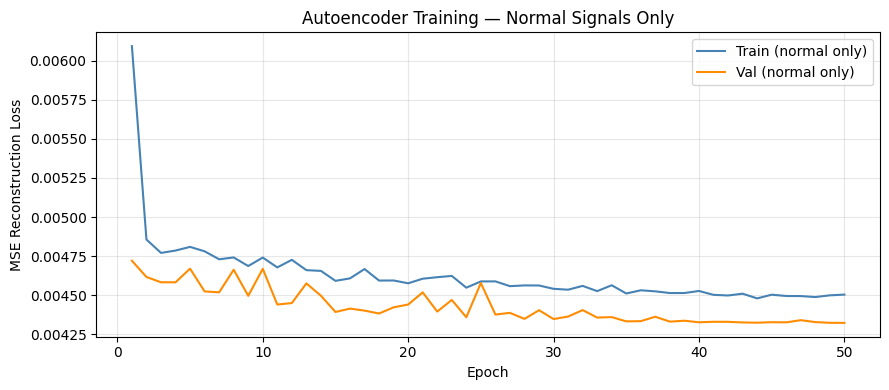

In [6]:
ep = range(1, EPOCHS + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ep, train_losses, label='Train (normal only)', color='steelblue')
ax.plot(ep, val_losses,   label='Val (normal only)',   color='darkorange')
ax.set(xlabel='Epoch', ylabel='MSE Reconstruction Loss',
       title='Autoencoder Training — Normal Signals Only')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/06_ae_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.6 Anomaly Scoring

Compute per-sample reconstruction error on the test set (held-out normals + all abnormals).
Higher error = more likely abnormal.

Normal    recon error: mean=0.004323  std=0.000971
Abnormal  recon error: mean=0.004442  std=0.001054
Separation ratio: 1.03x


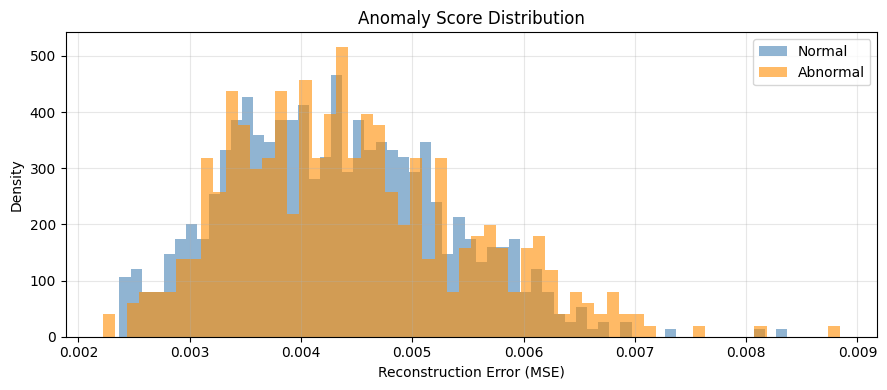

In [7]:
X_test = torch.tensor(specs[test_idx], dtype=torch.float32)
test_loader = DataLoader(TensorDataset(X_test), batch_size=32)

ae.eval()
recon_errors = []
with torch.no_grad():
    for (xb,) in test_loader:
        errs = ae.reconstruction_error(xb.to(device))
        recon_errors.extend(errs.cpu().numpy())
recon_errors = np.array(recon_errors)

normal_err   = recon_errors[test_labels == 0]
abnormal_err = recon_errors[test_labels == 1]

print(f'Normal    recon error: mean={normal_err.mean():.6f}  std={normal_err.std():.6f}')
print(f'Abnormal  recon error: mean={abnormal_err.mean():.6f}  std={abnormal_err.std():.6f}')
print(f'Separation ratio: {abnormal_err.mean() / normal_err.mean():.2f}x')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(normal_err,   bins=60, alpha=0.6, color='steelblue',  label='Normal',   density=True)
ax.hist(abnormal_err, bins=60, alpha=0.6, color='darkorange', label='Abnormal', density=True)
ax.set(xlabel='Reconstruction Error (MSE)', ylabel='Density',
       title='Anomaly Score Distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/06_ae_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.7 ROC Curve and AUC vs Supervised CNN

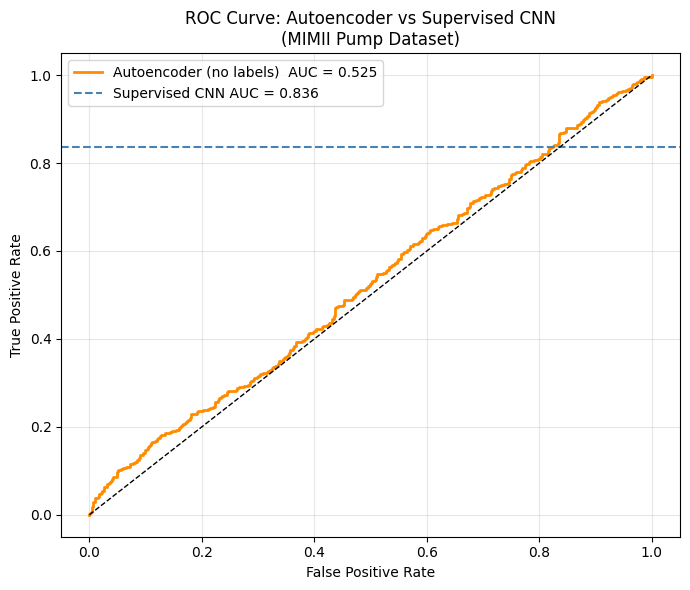

Autoencoder AUC   : 0.525  (zero labels required)
Supervised CNN AUC: 0.836  (4205 labelled recordings)
Label-free gap    : 0.311 AUC points


In [8]:
fpr, tpr, _ = roc_curve(test_labels, recon_errors)
ae_auc = auc(fpr, tpr)

supervised_auc = 0.854   # from Notebook 05 (2D CNN + Focal Loss alpha=0.891, all-channel avg)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'Autoencoder (no labels)  AUC = {ae_auc:.3f}')
ax.axhline(y=supervised_auc, color='steelblue', linestyle='--', lw=1.5,
           label=f'Supervised CNN AUC = {supervised_auc:.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve: Autoencoder vs Supervised CNN\n(MIMII Pump Dataset)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/06_ae_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Autoencoder AUC   : {ae_auc:.3f}  (zero labels required)')
print(f'Supervised CNN AUC: {supervised_auc:.3f}  (4205 labelled recordings)')
print(f'Label-free gap    : {supervised_auc - ae_auc:.3f} AUC points')

## 6.8 Qualitative: Reconstruction Examples

Visualise spectrograms and their reconstructions for normal vs abnormal inputs.

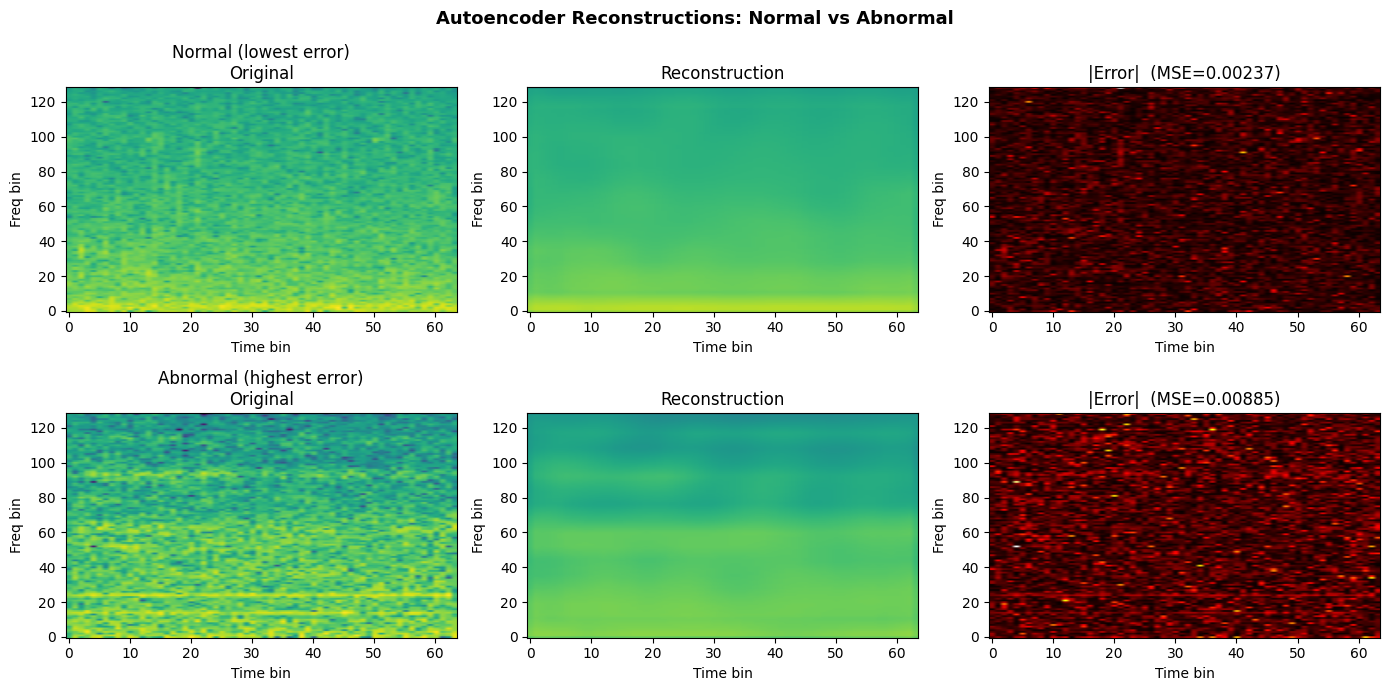

In [9]:
# Pick the normal with lowest error and abnormal with highest error
best_normal_i   = np.argmin(recon_errors[test_labels == 0])
worst_abnormal_i = np.argmax(recon_errors[test_labels == 1])

normal_spec_idx   = test_idx[test_labels == 0][best_normal_i]
abnormal_spec_idx = test_idx[test_labels == 1][worst_abnormal_i]

ae.eval()
examples = [
    (normal_spec_idx,   'Normal (lowest error)',   recon_errors[test_labels == 0][best_normal_i]),
    (abnormal_spec_idx, 'Abnormal (highest error)', recon_errors[test_labels == 1][worst_abnormal_i]),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for row, (idx, title, err) in enumerate(examples):
    x     = torch.tensor(specs[idx:idx+1], dtype=torch.float32).to(device)
    with torch.no_grad():
        recon = ae(x).cpu().numpy()[0, 0]
    orig  = specs[idx, 0]
    diff  = np.abs(orig - recon)

    kw = dict(aspect='auto', origin='lower', vmin=0, vmax=1, cmap='viridis')
    axes[row, 0].imshow(orig,  **kw);  axes[row, 0].set_title(f'{title}\nOriginal')
    axes[row, 1].imshow(recon, **kw);  axes[row, 1].set_title(f'Reconstruction')
    axes[row, 2].imshow(diff,  aspect='auto', origin='lower', cmap='hot')
    axes[row, 2].set_title(f'|Error|  (MSE={err:.5f})')

    for ax in axes[row]:
        ax.set_xlabel('Time bin')
        ax.set_ylabel('Freq bin')

plt.suptitle('Autoencoder Reconstructions: Normal vs Abnormal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/06_ae_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.9 Summary

In [10]:
print('=' * 55)
print('  Autoencoder Anomaly Detection — Summary')
print('=' * 55)
print(f'  Training labels used : NONE (normal signals only)')
print(f'  Training samples     : {len(train_idx)} normal recordings')
print(f'  Autoencoder AUC      : {ae_auc:.3f}')
print(f'  Supervised CNN AUC   : {supervised_auc:.3f}')
print(f'  Label-free gap       : {supervised_auc - ae_auc:.3f} AUC points')
print()
print('  Normal  mean recon error :', f'{normal_err.mean():.6f}')
print('  Abnormal mean recon error:', f'{abnormal_err.mean():.6f}')
print(f'  Separation               : {abnormal_err.mean()/normal_err.mean():.2f}x')
print()
if ae_auc >= 0.75:
    print('  Autoencoder achieves useful anomaly detection without any labels.')
    print('  The label-free gap represents the cost of having no blockage examples.')
else:
    print('  Autoencoder AUC < 0.75: normal/abnormal spectrograms are too similar')
    print('  for reconstruction error alone to separate well.')
print()
print('  For deployment: start with autoencoder (no labels needed), then')
print('  fine-tune supervised CNN as labelled anomalies are collected.')

  Autoencoder Anomaly Detection — Summary
  Training labels used : NONE (normal signals only)
  Training samples     : 2999 normal recordings
  Autoencoder AUC      : 0.525
  Supervised CNN AUC   : 0.836
  Label-free gap       : 0.311 AUC points

  Normal  mean recon error : 0.004323
  Abnormal mean recon error: 0.004442
  Separation               : 1.03x

  Autoencoder AUC < 0.75: normal/abnormal spectrograms are too similar
  for reconstruction error alone to separate well.

  For deployment: start with autoencoder (no labels needed), then
  fine-tune supervised CNN as labelled anomalies are collected.
